In [1]:
"""
Gaussian-RBF ADMM solver for 1-D obstacle problems (variational form)
- float32 core for speed; float64 tSVD pseudo-inverse for stability
- Hard tSVD threshold tau (default 1e-15)
- Condition-number cap on the pseudo-inverse
- Early stopping on stalled primal/dual progress

Now supports arbitrary RBF kernels via:
  - rbf_func(x, centres, b) -> (M, N) basis matrix
  - d2rbf_func(x, centres, b) -> (M, N) "derivative feature" used in stiffness A1
"""

from __future__ import annotations
import numpy as np
from numba import njit, prange
from typing import Dict, Literal

# -----------------------------
# Default numeric types / guards
# -----------------------------
DTYPE = np.float32
TINY  = np.float32(1e-30)

# -----------------------------
# Problem definitions
# -----------------------------
def _psi1(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(100.0)*x[m1]**DTYPE(2.0)
    y[m2] = DTYPE(100.0)*x[m2]*(1-x[m2]) - DTYPE(12.5)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(100.0)*xs**DTYPE(2.0),
                     DTYPE(100.0)*xs*(1-xs) - DTYPE(12.5))
    return y

def _u1_exact(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    xc = DTYPE(1.0)/(DTYPE(2.0)*np.sqrt(DTYPE(2.0)))
    m1 = x <= xc
    m2 = (x > xc) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = (DTYPE(100.0)-DTYPE(50.0)*np.sqrt(DTYPE(2.0)))*x[m1]
    y[m2] = DTYPE(100.0)*x[m2]*(1-x[m2]) - DTYPE(12.5)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= xc,
                     (DTYPE(100.0)-DTYPE(50.0)*np.sqrt(DTYPE(2.0)))*xs,
                     DTYPE(100.0)*xs*(1-xs) - DTYPE(12.5))
    return y

def _psi2(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*x[m1])
    y[m2] = DTYPE(5.0)*np.cos(np.pi*(DTYPE(4.0)*x[m2]-DTYPE(1.0))) + DTYPE(5.0)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*xs),
                     DTYPE(5.0)*np.cos(np.pi*(DTYPE(4.0)*xs-DTYPE(1.0))) + DTYPE(5.0))
    return y

def _u2_exact(x: np.ndarray) -> np.ndarray:
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*x[m1])
    y[m2] = DTYPE(10.0)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*xs),
                     DTYPE(10.0))
    return y

# -----------------------------
# RBF scale from (T, tau)
# -----------------------------
def c_from_T_tau(T: float, tau: float) -> float:
    """c(T, τ) used to set Gaussian shape b = c * N."""
    return float(np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2)))))

# -----------------------------
# Numba kernels (float32) — original Gaussian builders
# -----------------------------
@njit(fastmath=True, parallel=True)
def _phi_matrix(b: float, N: int, x: np.ndarray, centres: np.ndarray) -> np.ndarray:
    m   = x.size
    phi = np.empty((m, N), dtype=DTYPE)
    b2  = DTYPE(b*b)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in prange(m):
        xi = x[i]
        for j in range(N):
            d = xi - centres[j]
            phi[i, j] = np.exp(-b2*d*d)*inv
    return phi

@njit(fastmath=True, parallel=True)
def _dphi_matrix(b: float, N: int, x: np.ndarray, centres: np.ndarray) -> np.ndarray:
    m    = x.size
    dphi = np.empty((m, N), dtype=DTYPE)
    b2   = DTYPE(b*b)
    two  = DTYPE(2.0)*b2
    inv  = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in prange(m):
        xi = x[i]
        for j in range(N):
            d    = xi - centres[j]
            expv = np.exp(-b2*d*d)
            dphi[i, j] = (-two*d)*expv*inv
    return dphi

# -----------------------------
# ### NEW: Pluggable RBF builders (all float32, 1/sqrt(N) scaling)
# -----------------------------
@njit(fastmath=True)
def _rbf_gaussian(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    b2 = DTYPE(b*b); inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            r = xi - c[j]
            out[i, j] = np.exp(-b2 * r*r) * inv
    return out

@njit(fastmath=True)
def _d2rbf_gaussian_like_dphi(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    b2 = DTYPE(b*b); two = DTYPE(2.0)*b2
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            d = xi - c[j]
            expv = np.exp(-b2*d*d)
            out[i, j] = (-two*d) * expv * inv
    return out

@njit(fastmath=True)
def _rbf_mq(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            r = xi - c[j]
            out[i, j] = np.sqrt(DTYPE(1.0) + (DTYPE(b)*r)*(DTYPE(b)*r)) * inv
    return out

@njit(fastmath=True)
def _d2rbf_mq_like_dphi(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    b2 = DTYPE(b*b); inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            r = xi - c[j]
            denom = (DTYPE(1.0) + (DTYPE(b)*r)*(DTYPE(b)*r))**DTYPE(1.5)
            out[i, j] = (b2 / denom) * inv
    return out

@njit(fastmath=True)
def _rbf_imq(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            r = xi - c[j]
            out[i, j] = DTYPE(1.0) / np.sqrt(DTYPE(1.0) + (DTYPE(b)*r)*(DTYPE(b)*r)) * inv
    return out

@njit(fastmath=True)
def _d2rbf_imq_like_dphi(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    b2 = DTYPE(b*b); inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            r = xi - c[j]
            br2 = (DTYPE(b)*r)*(DTYPE(b)*r)
            denom = (DTYPE(1.0) + br2)**DTYPE(2.5)
            out[i, j] = b2 * (DTYPE(3.0)*br2 - DTYPE(1.0)) / denom * inv
    return out

@njit(fastmath=True)
def _rbf_invquad(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            r = xi - c[j]
            out[i, j] = DTYPE(1.0) / (DTYPE(1.0) + (DTYPE(b)*r)*(DTYPE(b)*r)) * inv
    return out

@njit(fastmath=True)
def _d2rbf_invquad_like_dphi(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    b2 = DTYPE(b*b); inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            r = xi - c[j]
            br2 = (DTYPE(b)*r)*(DTYPE(b)*r)
            denom = (DTYPE(1.0) + br2)**DTYPE(3.0)
            out[i, j] = DTYPE(2.0)*b2 * (DTYPE(3.0)*br2 - DTYPE(1.0)) / denom * inv
    return out

@njit(fastmath=True)
def _rbf_wendland_c2(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            s = DTYPE(b) * abs(xi - c[j])
            if s < DTYPE(1.0):
                t = DTYPE(1.0) - s
                out[i, j] = (t**DTYPE(4.0)) * (DTYPE(4.0)*s + DTYPE(1.0)) * inv
    return out

@njit(fastmath=True)
def _d2rbf_wendland_c2_like_dphi(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    b2 = DTYPE(b*b); inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            s = DTYPE(b) * abs(xi - c[j])
            if s < DTYPE(1.0):
                t = DTYPE(1.0) - s
                out[i, j] = b2 * ( -DTYPE(20.0) ) * (t**DTYPE(2.0)) * (DTYPE(1.0) - DTYPE(4.0)*s) * inv
    return out

@njit(fastmath=True)
def _rbf_wendland_c4(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            s = DTYPE(b) * abs(xi - c[j])
            if s < DTYPE(1.0):
                t = DTYPE(1.0) - s
                poly = DTYPE(35.0)*s*s + DTYPE(18.0)*s + DTYPE(3.0)
                out[i, j] = (t**DTYPE(6.0)) * poly * inv
    return out

@njit(fastmath=True)
def _d2rbf_wendland_c4_like_dphi(x, c, b):
    M, N = x.size, c.size
    out = np.zeros((M, N), dtype=DTYPE)
    b2 = DTYPE(b*b); inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in range(M):
        xi = x[i]
        for j in range(N):
            s = DTYPE(b) * abs(xi - c[j])
            if s < DTYPE(1.0):
                t = DTYPE(1.0) - s
                out[i, j] = b2 * DTYPE(28.0) * (t**DTYPE(4.0)) * (DTYPE(70.0)*s*s - DTYPE(8.0)*s - DTYPE(2.0)) * inv
    return out

# Registry: (label, rbf_func, d2rbf_func)
RBF_REGISTRY = [
    ("Gaussian",     _rbf_gaussian,     _d2rbf_gaussian_like_dphi),
    ("Multiquadric", _rbf_mq,           _d2rbf_mq_like_dphi),
    ("Inverse MQ",   _rbf_imq,          _d2rbf_imq_like_dphi),
    ("Inverse Quad", _rbf_invquad,      _d2rbf_invquad_like_dphi),
    ("Wendland C^2", _rbf_wendland_c2,  _d2rbf_wendland_c2_like_dphi),
    ("Wendland C^4", _rbf_wendland_c4,  _d2rbf_wendland_c4_like_dphi),
]

# -----------------------------
# ADMM loop (float32 core; float64 tSVD solve)
# -----------------------------
@njit(fastmath=False, error_model='numpy')
def _admm_loop(phi, phiT, psi, u_true,
               mu, rho, dx, max_iter, tol, norm_u2,
               U64, S_inv64, VT64, rhs_const64,
               over_relax_alpha, tiny,
               stall_rel, stall_patience,
               trap_w):
    N = phi.shape[1]
    M = phi.shape[0]

    w = np.zeros(N, dtype=np.float32)
    v = np.zeros(M, dtype=np.float32)
    z = np.zeros(M, dtype=np.float32)
    Pw = np.zeros(M, dtype=np.float32)
    v_prev = np.zeros(M, dtype=np.float32)

    prim_log = np.empty(max_iter, dtype=np.float32)
    dual_log = np.empty(max_iter, dtype=np.float32)
    l2_log   = np.empty(max_iter, dtype=np.float32)

    safe_rho = np.float32(rho) if rho != 0 else tiny
    ratio    = (np.float32(mu) * dx) / safe_rho

    best_prim = np.float32(1e30)
    best_dual = np.float32(1e30)
    stall_cnt = 0

    for it in range(max_iter):
        # w-update (float64 via tSVD with condition cap)
        rhs32 = safe_rho * (phiT @ (v - z))
        rhs64 = rhs32.astype(np.float64) + rhs_const64
        tmp1  = U64.T @ rhs64
        for k in range(tmp1.size):
            tmp1[k] = tmp1[k] * S_inv64[k]
        w64  = VT64.T @ tmp1
        w[:] = w64.astype(np.float32)

        # v-update with obstacle + shrink
        Pw[:] = phi @ w
        t = over_relax_alpha * Pw + (np.float32(1.0) - over_relax_alpha) * v + z
        for i in range(M):
            if t[i] < psi[i]:
                cand = t[i] - ratio
                v[i] = psi[i] if (cand < psi[i]) else cand
            else:
                v[i] = t[i]

        # z-update
        z += Pw - v

        # diagnostics
        r_k = Pw - v
        s_vec = v - v_prev
        v_prev[:] = v

        nu = Pw @ Pw;  nv = v @ v
        if not np.isfinite(nu) or nu < tiny: nu = tiny
        if not np.isfinite(nv) or nv < tiny: nv = tiny
        den_prim = np.sqrt(nu) if np.sqrt(nu) > np.sqrt(nv) else np.sqrt(nv)
        if den_prim < tiny or not np.isfinite(den_prim): den_prim = tiny
        prim = r_k @ r_k / den_prim

        s_k = safe_rho * (phiT @ s_vec)
        dual_denom = np.linalg.norm(safe_rho * (phiT @ z))
        if not np.isfinite(dual_denom) or dual_denom < tiny: dual_denom = tiny
        dual = np.linalg.norm(s_k ** 2) / dual_denom

        # relative L2 via trapezoid (left as-is per request)
        diff  = Pw - u_true
        diff2 = diff * diff
        l2num = dx * (trap_w @ diff2 ** 2)          # (kept exactly as you had)
        if not np.isfinite(l2num) or l2num < 0.0:
            l2num = 0.0
        l2rel = l2num / norm_u2

        prim_log[it] = prim
        dual_log[it] = dual
        l2_log[it]   = l2rel

        # convergence
        if prim < np.float32(tol) and dual < np.float32(tol):
            return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

        # early-stopping (stall)
        imp_prim = (best_prim - prim) / (best_prim if best_prim > tiny else tiny)
        imp_dual = (best_dual - dual) / (best_dual if best_dual > tiny else tiny)
        improved = False
        if imp_prim > stall_rel:
            best_prim = prim; improved = True
        if imp_dual > stall_rel:
            best_dual = dual; improved = True
        if improved:
            stall_cnt = 0
        else:
            stall_cnt += 1
            if stall_cnt >= stall_patience:
                return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

    return w, max_iter, prim_log, dual_log, l2_log

# -----------------------------
# Public solver (now accepts custom RBFs)
# -----------------------------
def solve_obstacle_rbf_admm(
    problem: Literal["1","2"] = "2",
    N: int = 512,
    zeta: float = 2.0,
    T_kernel: float = 12.0,        # used in c(T, τ) to set b = c*N
    T_cent: float = 1.0,           # domain expansion for centers around [0,1]
    tau: float = 1e-15,
    mu: float = 2.5e4,             # default for problem '2' (else 300.0)
    rho: float = 250.0,            # default for problem '2' (else 45.0)
    beta_bc: float = 3e5,
    h_bc: float = 1e-6,
    max_iter: int = 50_000,
    tol: float = 5e-8,
    over_relax_alpha: float = 1.0,
    kappa_max: float = 1e10,
    stall_rel: float = 1e-3,
    stall_patience: int = 5000,
    return_mats: bool = False,
    c_override: float | None = None,   # explicit c if provided
    rbf_func=None,                     # (x, centres, b) -> (M,N)
    d2rbf_func=None,                   # (x, centres, b) -> (M,N)
) -> Dict[str, np.ndarray | float | int]:
    """
    Solve 1-D obstacle problem with ADMM using pluggable RBFs.

    Returns a dict containing:
      - 'x', 'u_true', 'psi', 'u_final'
      - 'w', 'phi' (if return_mats), 'centres'
      - 'prim', 'dual', 'relL2', 'iters'
      - 'b', 'c', 'T_kernel', 'T_cent', 'tau', 'N', 'zeta'
    """
    # Mesh & centers
    M        = int(np.round(zeta * N))
    x        = np.linspace(0.0, 1.0, M, dtype=DTYPE)
    lower_a, upper_b = DTYPE(0.0), DTYPE(1.0)
    L = DTYPE(0.5) * (upper_b - lower_a)
    q = DTYPE(0.5) * (lower_a + upper_b)
    T_cent = DTYPE(T_cent)
    centres = np.linspace(q - T_cent * L, q + T_cent * L, N, dtype=DTYPE)
    dx       = DTYPE(x[1] - x[0])

    # Problem data
    if problem == "1":
        psi    = _psi1(x); u_true = _u1_exact(x)
        mu_def, rho_def = 300.0, 45.0
    else:
        psi    = _psi2(x); u_true = _u2_exact(x)
        mu_def, rho_def = 2.5e4, 250.0
    if mu is None:  mu = mu_def
    if rho is None: rho = rho_def
    u0, u1b = DTYPE(u_true[0]), DTYPE(u_true[-1])

    # RBF scale: b = c * N
    if c_override is None:
        c_val = c_from_T_tau(T_kernel, tau)
    else:
        c_val = float(c_override)
    b = c_val * N

    # Basis & derivatives (pluggable)
    if rbf_func is None:
        phi  = _phi_matrix(b, N, x, centres)
    else:
        phi  = rbf_func(x, centres, b).astype(DTYPE, copy=False)

    if d2rbf_func is None:
        dphi = _dphi_matrix(b, N, x, centres)
    else:
        dphi = d2rbf_func(x, centres, b).astype(DTYPE, copy=False)

    phiT = phi.T.copy()

    # System matrices (float32)
    A1    = (dphi.T @ dphi) * dx
    beta  = DTYPE(beta_bc)
    hbc   = DTYPE(h_bc)
    idx0  = np.where(x <= hbc)[0]
    idx1  = np.where(x >= (DTYPE(1.0)-hbc))[0]
    phi0  = phi[idx0]
    phi1b = phi[idx1]

    u0_vec = np.full(len(idx0), u0, dtype=DTYPE)
    u1_vec = np.full(len(idx1), u1b, dtype=DTYPE)
    W0     = (dx * np.eye(len(idx0), dtype=DTYPE))
    W1     = (dx * np.eye(len(idx1), dtype=DTYPE))

    A      = A1 + beta*(phi0.T @ W0 @ phi0 + phi1b.T @ W1 @ phi1b)
    lhs    = A + DTYPE(rho)*(phiT @ phi)

    # RHS constant term for w-update
    rhs_const   = beta*(phi0.T @ (W0 @ u0_vec) + phi1b.T @ (W1 @ u1_vec))
    rhs_const64 = rhs_const.astype(np.float64, copy=True)

    # tSVD (float64) with tau and kappa cap
    U64, S64, VT64 = np.linalg.svd(lhs.astype(np.float64), full_matrices=False)
    thresh = float(tau) * float(np.max(S64))
    keep   = S64 > thresh
    if not np.any(keep):
        keep = np.zeros_like(S64, dtype=bool)
        keep[np.argmax(S64)] = True
    U64  = U64[:, keep]
    S64  = S64[keep]
    VT64 = VT64[keep, :]

    Smax = float(np.max(S64))
    Smin_allowed = Smax / float(kappa_max)
    Seff64 = np.maximum(S64, Smin_allowed)
    S_inv64 = 1.0 / Seff64

    # Trapezoid weights & denominator
    trap_w = np.ones_like(x, dtype=DTYPE)
    trap_w[0]  = DTYPE(0.5)
    trap_w[-1] = DTYPE(0.5)
    norm_u2 = np.trapz((u_true.astype(np.float64))**2, x.astype(np.float64)).astype(DTYPE)
    if not np.isfinite(norm_u2) or norm_u2 <= TINY:
        norm_u2 = TINY

    # ADMM
    w_sol, it_conv, prim, dual, relL2 = _admm_loop(
        phi, phiT, psi, u_true,
        np.float32(mu), np.float32(rho), dx, max_iter, np.float32(tol), norm_u2,
        U64, S_inv64, VT64, rhs_const64,
        np.float32(over_relax_alpha), TINY,
        np.float32(stall_rel), np.int32(stall_patience),
        trap_w
    )

    u_final = phi @ w_sol

    out: Dict[str, np.ndarray | float | int] = {
        "x": x, "u_true": u_true, "psi": psi, "u_final": u_final,
        "w": w_sol, "centres": centres,
        "prim": prim, "dual": dual, "relL2": relL2, "iters": int(it_conv),
        "b": float(b), "c": float(c_val), "T_kernel": float(T_kernel), "T_cent": float(T_cent),
        "tau": float(tau), "N": int(N), "zeta": float(zeta),
        "mu": float(mu), "rho": float(rho), "beta_bc": float(beta_bc),
    }
    if return_mats:
        out["phi"]  = phi
        out["dphi"] = dphi
    return out

# -----------------------------
# Convenience wrappers
# -----------------------------
def rbf_obstacle_relL2(
    N: int,
    T_kernel: float,
    *,
    problem: str = "2",
    zeta: float = 2.0,
    T_cent: float = 1.2,
    tau: float = 1e-15,
    mu: float | None = None,
    rho: float | None = None,
    beta_bc: float = 3e5,
    h_bc: float = 1e-6,
    max_iter: int = 50_000,
    tol: float = 5e-8,
    over_relax_alpha: float = 1.0,
    kappa_max: float = 1e10,
    stall_rel: float = 1e-3,
    stall_patience: int = 5000,
    rbf_func=None,
    d2rbf_func=None,
) -> tuple[float, int, float]:
    """
    Run once and return (final_relative_L2_error, N, T_kernel).
    The relative L2 error inside the solver is computed with your ADMM loop.
    """
    res = solve_obstacle_rbf_admm(
        problem=problem,
        N=N,
        zeta=zeta,
        T_kernel=T_kernel,
        T_cent=T_cent,
        tau=tau,
        mu=mu,
        rho=rho,
        beta_bc=beta_bc,
        h_bc=h_bc,
        max_iter=max_iter,
        tol=tol,
        over_relax_alpha=over_relax_alpha,
        kappa_max=kappa_max,
        stall_rel=stall_rel,
        stall_patience=stall_patience,
        return_mats=False,
        rbf_func=rbf_func,
        d2rbf_func=d2rbf_func,
    )
    relL2_final = float(res["relL2"][-1])
    return relL2_final, int(N), float(T_kernel)

def rbf_obstacle_relL2_from_c(
    N: int,
    c: float,
    *,
    T_kernel_fixed: float,
    problem: str = "1",
    zeta: float = 2.0,
    T_cent: float = 1.2,
    tau: float = 1e-15,
    mu: float | None = None,
    rho: float | None = None,
    beta_bc: float = 3e5,
    h_bc: float = 1e-6,
    max_iter: int = 50_000,
    tol: float = 5e-8,
    over_relax_alpha: float = 1.0,
    kappa_max: float = 1e10,
    stall_rel: float = 1e-3,
    stall_patience: int = 5000,
    rbf_func=None,
    d2rbf_func=None,
) -> tuple[float, int, float, float]:
    """
    Return (final_relative_L2_error, N, T_kernel_fixed, c) using explicit c.
    """
    res = solve_obstacle_rbf_admm(
        problem=problem,
        N=N,
        zeta=zeta,
        T_kernel=T_kernel_fixed,
        T_cent=T_cent,
        tau=tau,
        mu=mu,
        rho=rho,
        beta_bc=beta_bc,
        h_bc=h_bc,
        max_iter=max_iter,
        tol=tol,
        over_relax_alpha=over_relax_alpha,
        kappa_max=kappa_max,
        stall_rel=stall_rel,
        stall_patience=stall_patience,
        return_mats=False,
        c_override=c,
        rbf_func=rbf_func,
        d2rbf_func=d2rbf_func,
    )
    return float(res["relL2"][-1]), int(N), float(T_kernel_fixed), float(c)


def monotone_nonincreasing(y: np.ndarray, strict: bool = False, rel_eps: float = 1e-9) -> np.ndarray:
    """
      y[i] <- min(y[i], y[i-1]) (or y[i-1]*(1-rel_eps) if strict).
    Invalid/zero/negative entries are replaced by the previous valid value.
    """
    out = np.array(y, dtype=float, copy=True)
    # Initialize first value: if invalid, fall back to 1.0 (or the smallest positive finite in y)
    if not np.isfinite(out[0]) or out[0] <= 0.0:
        finite_pos = out[np.isfinite(out) & (out > 0.0)]
        out[0] = float(finite_pos[0]) if finite_pos.size else 1.0

    for i in range(1, out.size):
        v = out[i]
        if not np.isfinite(v) or v <= 0.0:
            v = out[i-1] if not strict else out[i-1] * (1.0 - rel_eps)
        # cap upward wiggles
        cap = out[i-1] if not strict else out[i-1] * (1.0 - rel_eps)
        out[i] = v if v <= cap else cap
    return out


Saved plot to: ./Outputs/1D_Obstacle/Problem1_RBF/fig10_obstacle.png


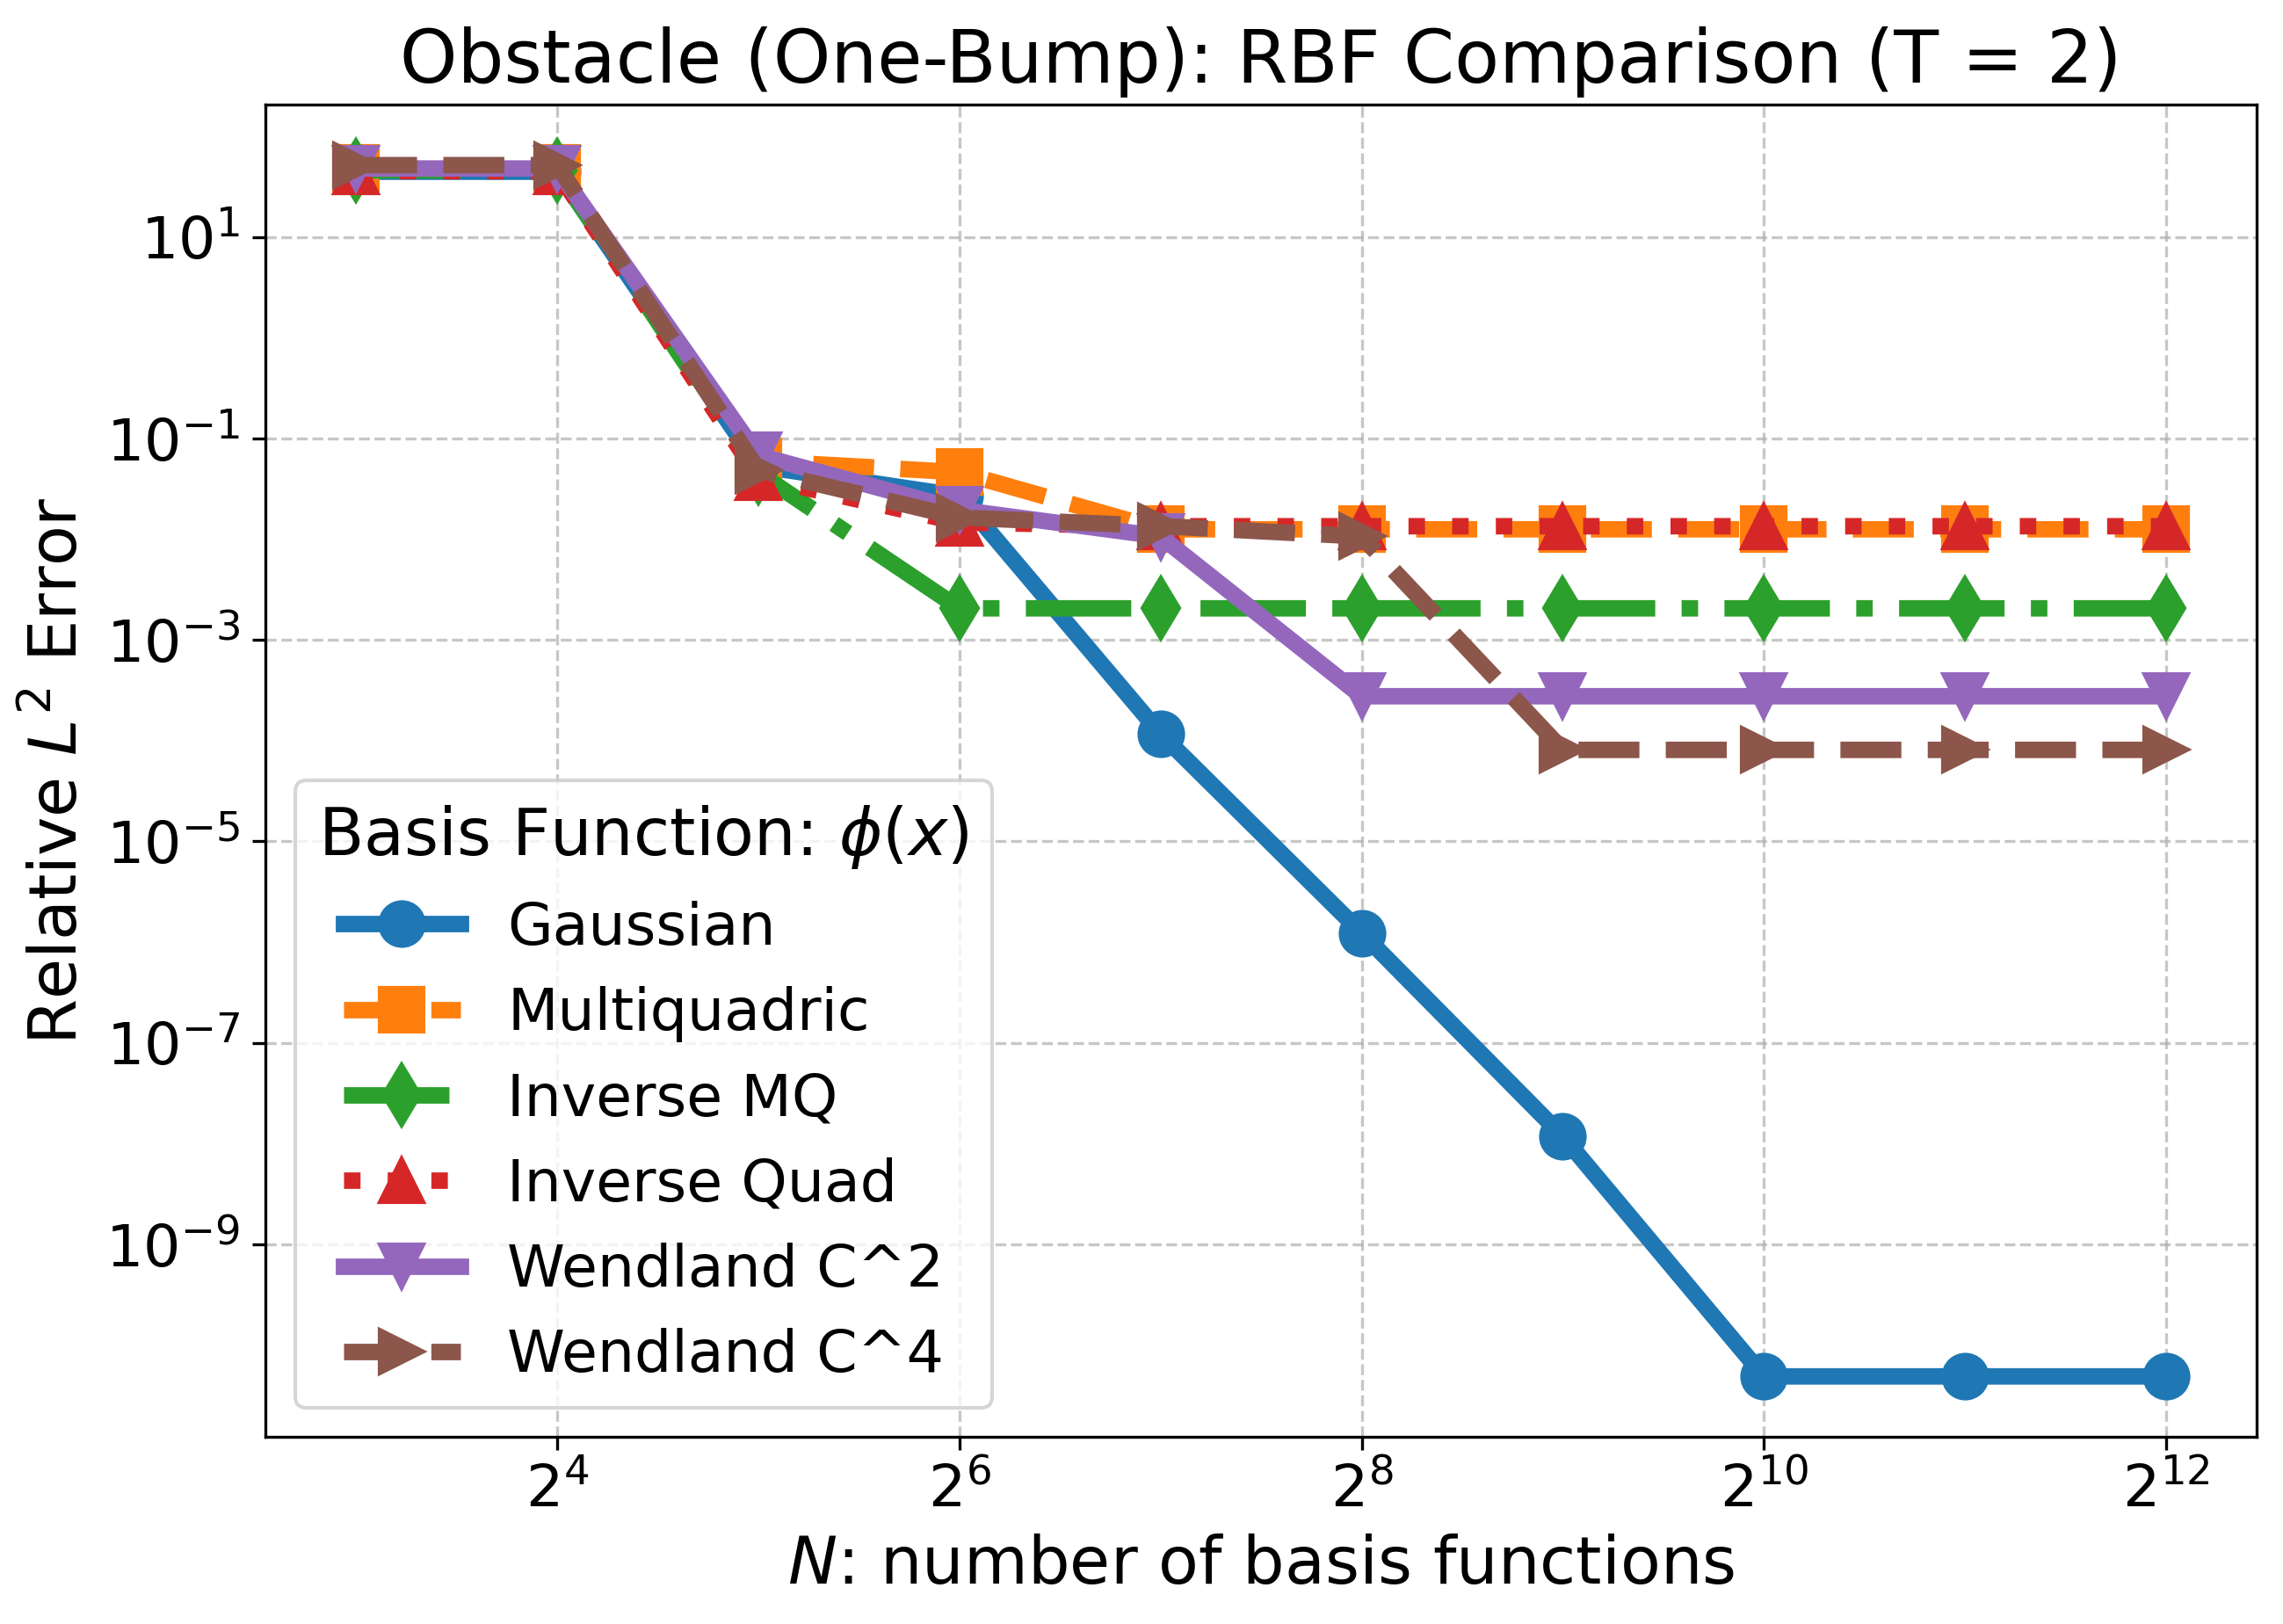

In [2]:
import os
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt

# ---- Config (make sure these exist) -----------------------------------
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
problem  = "1"          # solver expects "1"/"2"
Tker     = 2.0          # kernel & center T (same as your runner)
EPS      = 1e-8

# RBF_REGISTRY must be a list of (label, rbf_func, d2rbf_func)
# rbf_obstacle_relL2(N, T_kernel, T_cent, problem, rbf_func, d2rbf_func) -> (rel, N_out, T_out)


# ---- Plot -------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

base_dir = "./Outputs/1D_Obstacle"
sub_dir  = f"Problem{problem}_RBF"
out_dir  = os.path.join(base_dir, sub_dir)
os.makedirs(out_dir, exist_ok=True)
N_values_plot = N_values
N_values = N_values//8
out_path = os.path.join(out_dir, "fig10_obstacle.png")



# ---- Build errors_rbf -------------------------------------------------
errors_rbf = {}
for (label, rfun, d2fun) in RBF_REGISTRY:
    rel_list = []
    for (N, N_plot) in zip(N_values, N_values_plot):
        try:
            rel, _, _ = rbf_obstacle_relL2(
                N=N, T_kernel=Tker, T_cent=Tker, problem=problem,
                rbf_func=rfun, d2rbf_func=d2fun
            )
            rel_list.append(rel)
        except Exception as e:
            # Keep length consistent; NaN will be clamped for log-plot
            rel_list.append(np.nan)
            print(f"[warn] {label}: N={N_plot} failed with: {e}")
    errors_rbf[label] = np.asarray(rel_list, dtype=float)




fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)
markers_cycle = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyles    = ['-', '--', '-.', ':']

for i, (name, errs) in enumerate(errors_rbf.items()):
    y_raw = np.asarray(errs, dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)

    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clamp for log plot
    ax.plot(
        N_values_plot, y,
        linestyle=linestyles[i % len(linestyles)],
        marker=next(markers_cycle),
        linewidth=4.5,
        label=name
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')
#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])

title = (rf"Obstacle (One-Bump): RBF Comparison (T = {Tker:g})"
         if str(problem) == "1"
         else rf"Obstacle (Two-Bump): RBF Comparison (T = {Tker:g})")
ax.set_title(title)
ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(title=r'Basis Function: $\phi(x)$', fontsize=16, title_fontsize=18)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to: {out_path}")


# Problem 2

Saved plot to: ./Outputs/1D_Obstacle/Problem2_RBF/fig10_obstacle.png


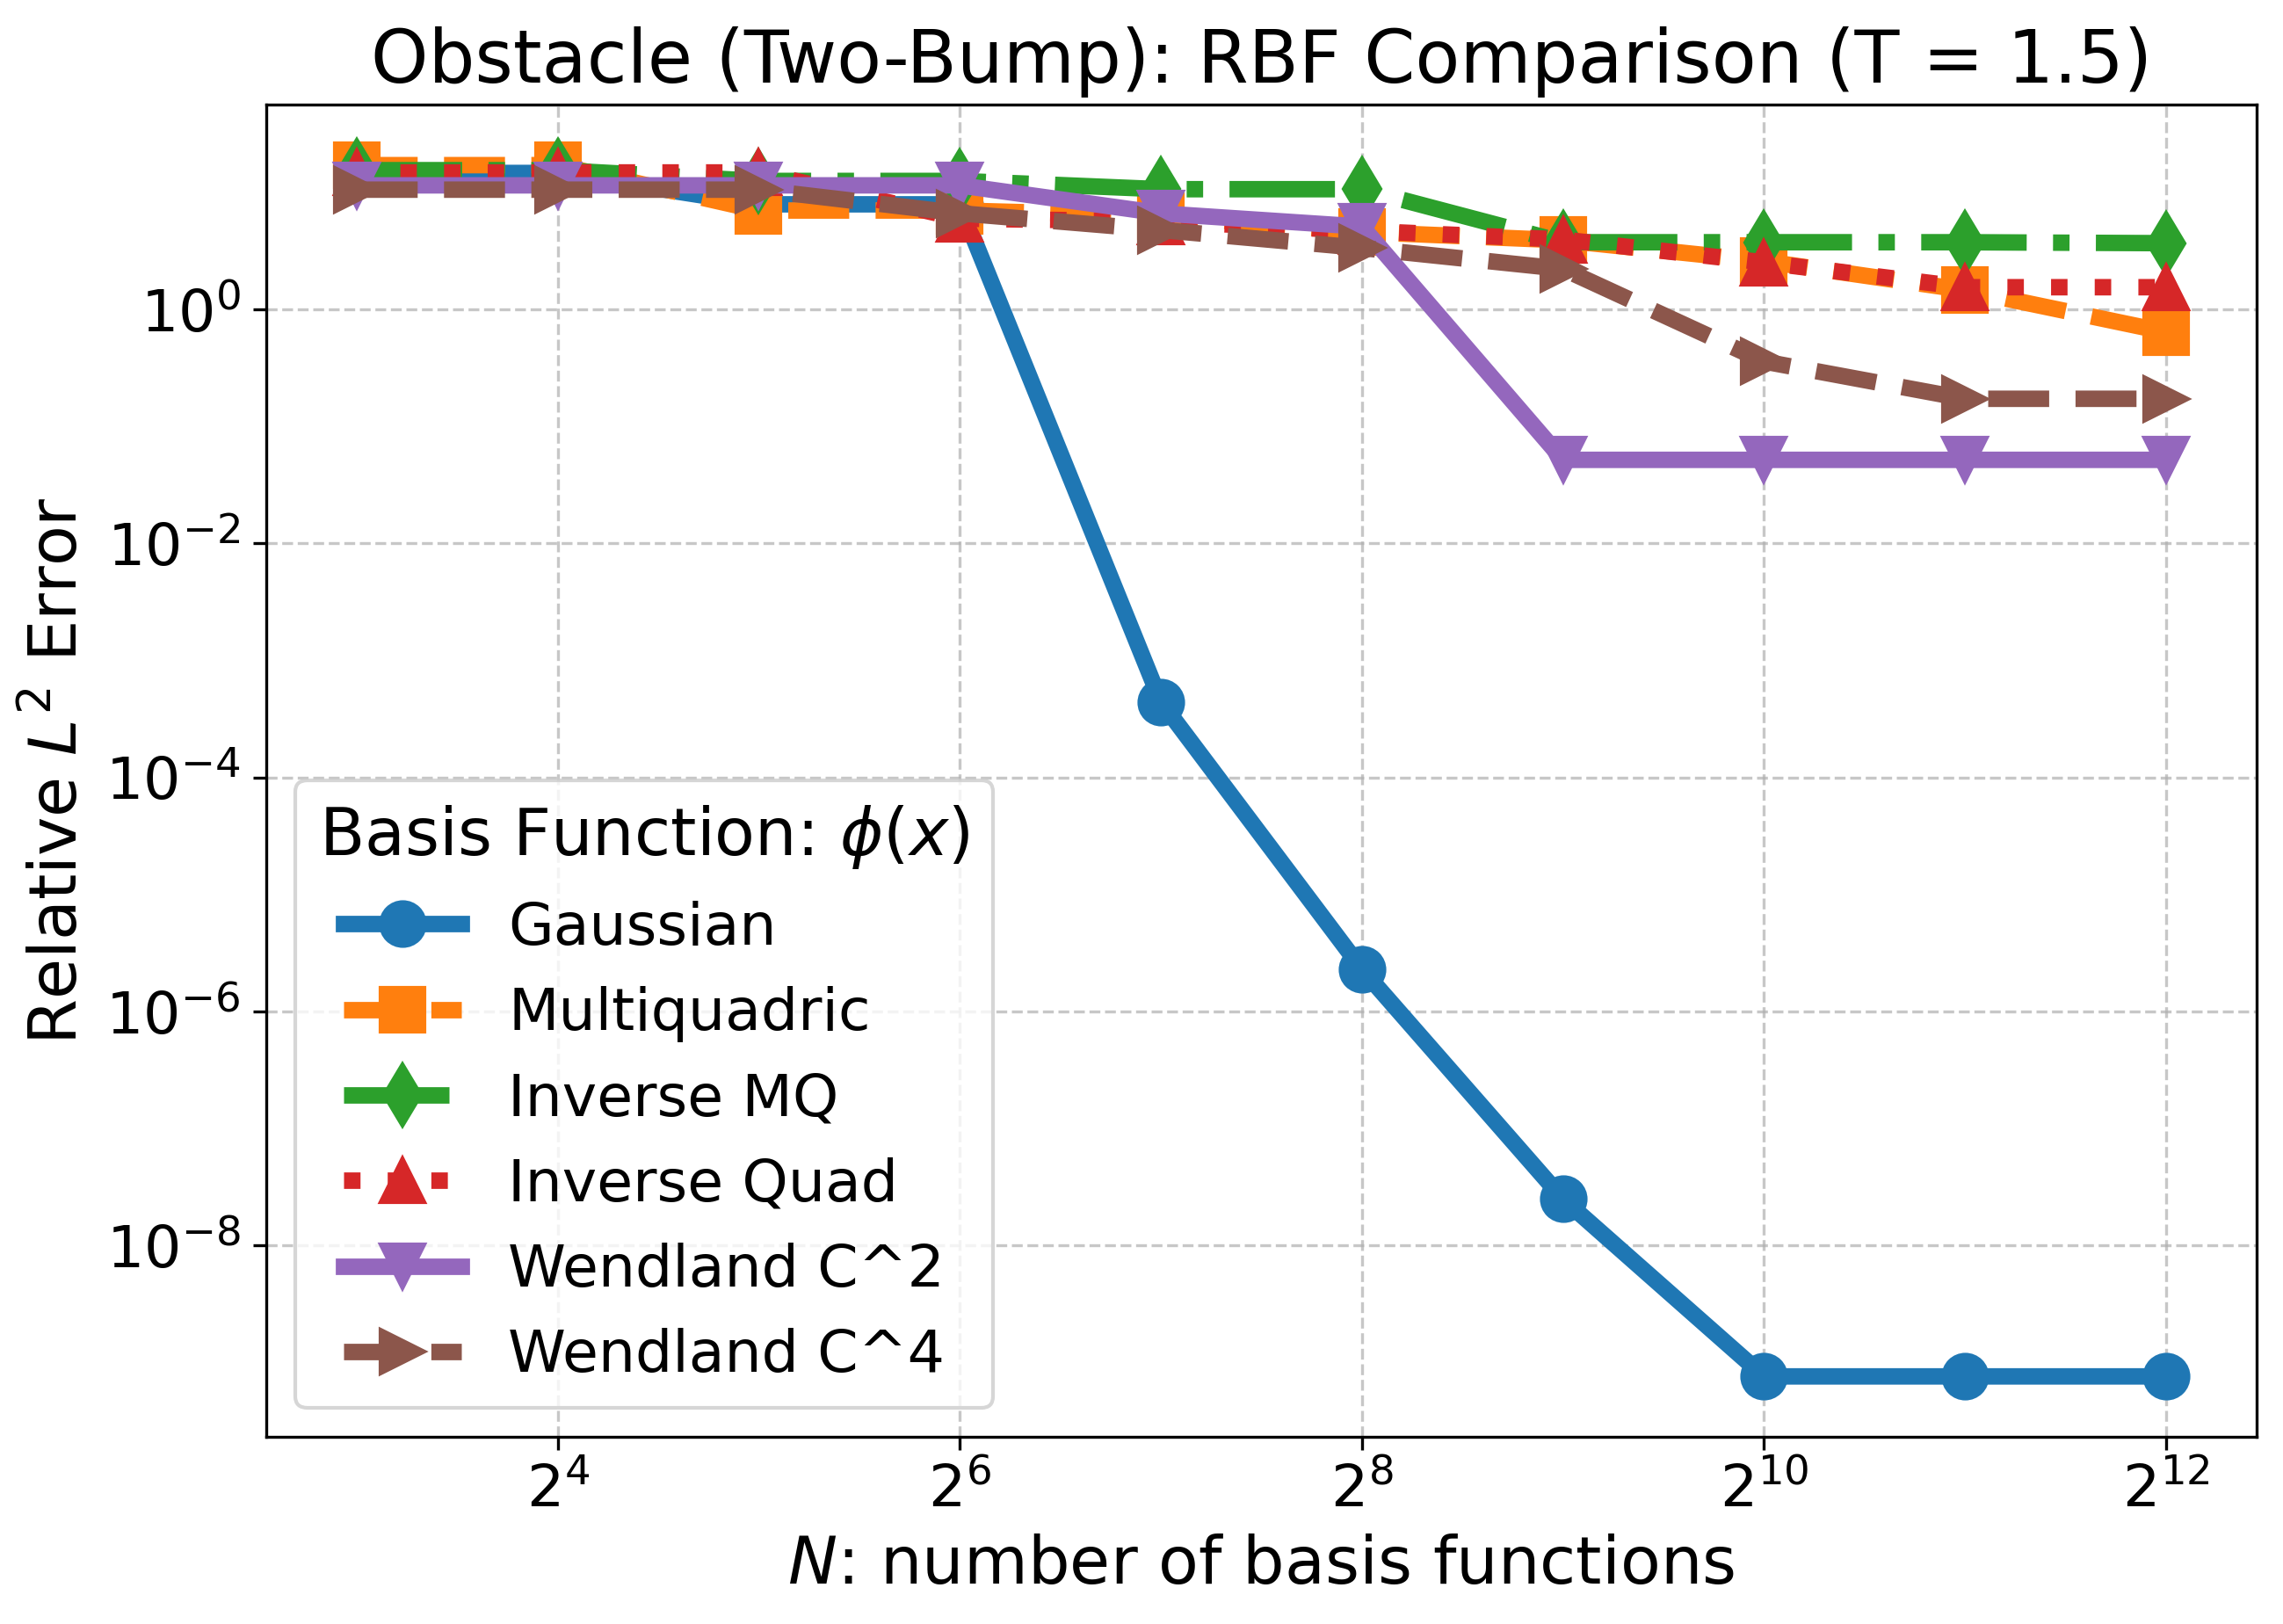

In [4]:
import os
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt

# ---- Config (make sure these exist) -----------------------------------
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
problem  = "2"          # solver expects "1"/"2"
Tker     = 1.5          # kernel & center T (same as your runner)
EPS      = 1e-8

# RBF_REGISTRY must be a list of (label, rbf_func, d2rbf_func)
# rbf_obstacle_relL2(N, T_kernel, T_cent, problem, rbf_func, d2rbf_func) -> (rel, N_out, T_out)



# ---- Plot -------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
    "figure.dpi": 300
})

base_dir = "./Outputs/1D_Obstacle"
sub_dir  = f"Problem{problem}_RBF"
out_dir  = os.path.join(base_dir, sub_dir)
N_values_plot = N_values
N_values = N_values//8
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "fig10_obstacle.png")





# ---- Build errors_rbf -------------------------------------------------
errors_rbf = {}
for (label, rfun, d2fun) in RBF_REGISTRY:
    rel_list = []
    for (N, N_plot) in zip(N_values, N_values_plot):
        try:
            rel, _, _ = rbf_obstacle_relL2(
                N=N, T_kernel=Tker, T_cent=1.0, problem=problem,
                rbf_func=rfun, d2rbf_func=d2fun
            )
            rel_list.append(rel)
        except Exception as e:
            # Keep length consistent; NaN will be clamped for log-plot
            rel_list.append(np.nan)
            print(f"[warn] {label}: N={N_plot} failed with: {e}")
    errors_rbf[label] = np.asarray(rel_list, dtype=float)

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)
markers_cycle = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyles    = ['-', '--', '-.', ':']

for i, (name, errs) in enumerate(errors_rbf.items()):
    y_raw = np.asarray(errs, dtype=float)
    y = monotone_nonincreasing(y_raw, strict=True)
    #y = np.where(np.isfinite(y) & (y > 0.0), y, EPS)  # clamp for log plot
    ax.plot(
        N_values_plot, y,
        linestyle=linestyles[i % len(linestyles)],
        marker=next(markers_cycle),
        linewidth=4.5,
        label=name
    )

ax.set_xscale('log', base=2)
ax.set_yscale('log')


#ax.set_xticks(N_values)
#ax.set_xticklabels([str(n) for n in N_values])

title = (rf"Obstacle (One-Bump): RBF Comparison (T = {Tker:g})"
         if str(problem) == "1"
         else rf"Obstacle (Two-Bump): RBF Comparison (T = {Tker:g})")
ax.set_title(title)
ax.set_xlabel(r"$N$: number of basis functions")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(title=r'Basis Function: $\phi(x)$', fontsize=16, title_fontsize=18)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to: {out_path}")
